# 2D FEP Subtraction Trial: 70:30 reference through FEP
### Tests `fep2d_v2.py` on one seeded dataset using the merged 70:30 EtOH:water reference

Keep `fep2d_v2.py` in the same folder as this notebook.

**What this answers**
1. Does the reference build cleanly (how many frames kept or rejected)?
2. Null test: subtracting the reference from a non-hit frame should leave nothing. If it doesn't, the reference or scale fit is wrong.
3. On diffraction frames, does 2D subtraction give a flatter baseline and clearer peaks than your 1D subtraction?
4. How much does the fitted scale factor drift across the run?

## Step 0: Paths

In [1]:
import os, glob, numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THESE ----
REF_DIR   = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/70_30_mid_ref/"           # raw .nxs frames of the 70:30 reference run
SAMPLE_DIR = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/CBZ_seed_mid_007/02_V7_diff_sorting_output/diffraction/"   # triage 'diffraction' .nxs
NONHIT_DIR = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/CBZ_seed_mid_007/02_V7_diff_sorting_output/background/"     # triage 'background' .nxs (for the null test)
MASK_PATH = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/Calib/X3_CBZcalib_mask.npy"  # optional: your mask .npy file; "" to skip
PONI_PATH = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/Calib/X3_CBZcalib.poni"
OUT_DIR   = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/Trial_2D_70_30/"
ONE_D_DIR = r"E:/I11BT_AP39_sept26_CBZ/Data_Processing/CBZ_seed_mid_007/CBZ_seed_mid_007_02_fep_corrected/subtracted/"   # optional: your 1D-subtracted .xy folder (…_02_fep_corrected) for comparison; "" to skip
# --------------------

os.makedirs(OUT_DIR, exist_ok=True)
ref_files    = sorted(glob.glob(os.path.join(REF_DIR, "*.nxs")))
sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "*.nxs")))
nonhit_files = sorted(glob.glob(os.path.join(NONHIT_DIR, "*.nxs")))
mask = np.load(MASK_PATH)
print(f"reference files: {len(ref_files)}  samples: {len(sample_files)}  non-hit: {len(nonhit_files)}")
print(f"mask: {mask.shape}, {100*mask.mean():.1f}% masked")

reference files: 99  samples: 96  non-hit: 42
mask: (2881, 2880), 0.8% masked


## Step 1: Build the merged 2D reference
Screening drops shutter-closed or off-position frames. Check the rejection list makes sense. If it rejects many frames, or none when you know some were bad, adjust `min_total_frac`, `z_total` or `min_corr`.

used 99 frames, rejected 0


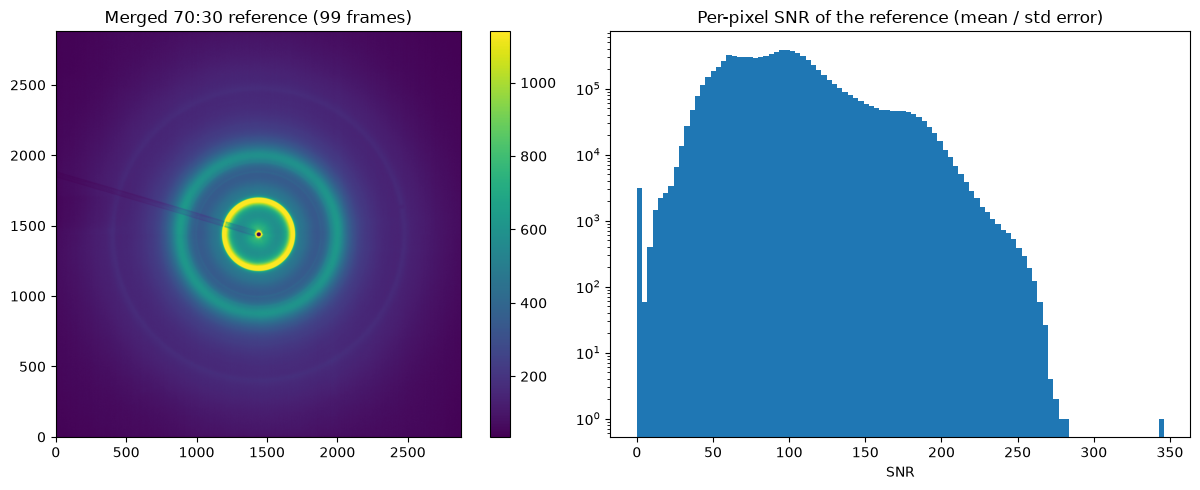

In [2]:
import importlib, fep2d_v2 as fm
importlib.reload(fm)

ref = fm.build_reference(ref_files, mask=mask, label="70:30 EtOH:H2O")
print(f"used {ref.n_used} frames, rejected {ref.n_rejected}")
for p, i, why in ref.rejected:
    print("  rejected:", os.path.basename(p), i, why)

fm.save_reference(ref, os.path.join(OUT_DIR, "ref_70_30.npz"))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
v = ref.mean[~mask.astype(bool)]
im = ax[0].imshow(ref.mean, origin="lower", vmin=np.percentile(v, 1), vmax=np.percentile(v, 99.5), cmap="viridis")
ax[0].set_title(f"Merged 70:30 reference ({ref.n_used} frames)"); plt.colorbar(im, ax=ax[0], fraction=0.046)
snr = ref.mean / np.sqrt(ref.var_of_mean + 1e-9)
ax[1].hist(snr[~mask.astype(bool)].ravel(), bins=100, log=True)
ax[1].set_title("Per-pixel SNR of the reference (mean / std error)"); ax[1].set_xlabel("SNR")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "step1_reference.png"), dpi=150); plt.show()

## Step 2: Null test (the most important check)
Subtract the reference from frames that should contain **no crystal** (triage "background" frames).
A good reference leaves residual noise centred on zero with no ring structure.
Residual rings mean composition or geometry mismatch. A strongly non-zero mean means the scale fit is off.

In [ ]:
import pyFAI
ai = pyFAI.load(PONI_PATH)
centre = fm.beam_centre_px(ai)
print("beam centre (row, col):", centre)

valid = ~mask.astype(bool)
test_nonhit = nonhit_files[:5]
rows = []
for p, i, fr in fm.iter_frames(test_nonhit):
    corr, info = fm.subtract_frame(fr, ref, mask)
    rows.append((os.path.basename(p), info["scale"], info["fit_pixel_frac"],
                 corr[valid].mean(), corr[valid].std(), fr[valid].mean()))
print(f"{'file':<24}{'scale':>8}{'fit_frac':>10}{'resid mean':>12}{'resid std':>11}{'raw mean':>10}")
for r in rows: print(f"{r[0]:<24}{r[1]:8.3f}{r[2]:10.3f}{r[3]:12.3f}{r[4]:11.2f}{r[5]:10.1f}")

# visual: raw / scaled reference / residual for the first non-hit frame
p, i, fr = next(fm.iter_frames(test_nonhit[:1]))
corr, info = fm.subtract_frame(fr, ref, mask)
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))
vmax = np.percentile(fr[valid], 99.5)
ax[0].imshow(fr, origin="lower", vmin=0, vmax=vmax); ax[0].set_title("Non-hit frame")
ax[1].imshow(info["scale"] * ref.mean, origin="lower", vmin=0, vmax=vmax); ax[1].set_title(f"Scaled reference (x{info['scale']:.3f})")
s = corr[valid].std()
ax[2].imshow(corr, origin="lower", vmin=-4*s, vmax=4*s, cmap="RdBu_r"); ax[2].set_title("Residual (should look like noise)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "step2_null_test.png"), dpi=150); plt.show()

## Step 3: Diffraction frames, 2D-corrected vs raw (and vs your 1D result)
Both patterns are integrated with the same settings as the app (no solid-angle correction), then **MOR baselined with the same half_window** so the comparison with your 1D workflow is fair.

Metrics to compare: standard deviation in a diagnostic region with no real peaks (lower = cleaner), and peak heights at reflections you trust.

In [ ]:
from pybaselines import Baseline

NPT, RMIN, RMAX = 2000, 1.0, 30.0
HALF_WINDOW = 4
DIAG = (7.0, 9.0)        # featureless region, same default as the app
TEST_FRAMES = sample_files[:6]    # <-- put frames with strong, known Bragg peaks here

def integrate(frame):
    r = ai.integrate1d(frame.astype(np.float32), NPT, unit=pyFAI.units.TTH_DEG,
                       radial_range=[RMIN, RMAX], mask=mask,
                       correctSolidAngle=False, error_model=None)
    return np.asarray(r.radial), np.asarray(r.intensity)

def baseline(x, y):
    return y - Baseline(x_data=x).mor(y, half_window=HALF_WINDOW)[0]

summary = []
for p, i, fr in fm.iter_frames(TEST_FRAMES):
    stem = os.path.splitext(os.path.basename(p))[0]
    corr, info = fm.subtract_frame(fr, ref, mask)
    x, y_raw = integrate(fr)
    _, y_2d = integrate(corr)
    b_raw, b_2d = baseline(x, y_raw), baseline(x, y_2d)

    curves = {"raw": b_raw, "2D corrected": b_2d}
    if ONE_D_DIR:
        cand = glob.glob(os.path.join(ONE_D_DIR, f"{stem}*.xy"))
        if cand:
            d = np.loadtxt(cand[0], skiprows=1)
            curves["1D corrected"] = baseline(d[:, 0], d[:, 1])
            curves_x = d[:, 0]
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for name, y in curves.items():
        xx = curves_x if name == "1D corrected" else x
        ax.plot(xx, y, lw=1, label=name)
    ax.axvspan(*DIAG, color="gray", alpha=0.1)
    ax.set_xlim(RMIN, RMAX); ax.set_xlabel("2θ (°)"); ax.set_ylabel("Intensity (baselined)")
    ax.set_title(f"{stem}  scale={info['scale']:.3f}"); ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f"step3_{stem}.png"), dpi=150); plt.show()

    m = (x >= DIAG[0]) & (x <= DIAG[1])
    summary.append(dict(frame=stem, scale=round(info["scale"], 3),
                        diag_std_raw=round(b_raw[m].std(), 2),
                        diag_std_2D=round(b_2d[m].std(), 2),
                        max_raw=round(b_raw.max(), 1), max_2D=round(b_2d.max(), 1)))
import pandas as pd
print(pd.DataFrame(summary).to_string(index=False))

## Step 4: Scale-factor drift across the run
Runs the full per-frame loop on the diffraction frames and plots the fitted scale against collection order.
A flat line means one reference holds all run. A trend means the reference needs refreshing or the scale needs a better fit region.
Also check `fit_pixel_frac` (fraction of pixels kept in the fit) and `neg_frac` (should be near 0.5 for a good subtraction).

In [ ]:
import pandas as pd
rows = fm.process_run(sample_files[:60], ref, os.path.join(OUT_DIR, "corrected_2D"),
                      mask=mask, ai=ai, xy_dir=os.path.join(OUT_DIR, "integrated_2Dcorr"),
                      write_nxs=False)      # set write_nxs=True to also save corrected .nxs files
df = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(df["order"], df["scale"], "o-", ms=3); ax[0].set_title("Fitted scale vs frame order")
ax[1].plot(df["order"], df["neg_frac"], "o-", ms=3); ax[1].axhline(0.5, color="gray", ls=":"); ax[1].set_title("Negative-pixel fraction")
ax[2].plot(df["order"], df["fit_pixel_frac"], "o-", ms=3); ax[2].set_title("Fraction of pixels kept in fit")
for a in ax: a.set_xlabel("frame order"); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "step4_drift.png"), dpi=150); plt.show()
print(df[["scale", "neg_frac", "fit_pixel_frac"]].describe().round(3))

## Step 5: Does the fit region matter?
Compares the scale from fitting all pixels against fitting only an annulus around the FEP ring.
If the two scales agree, the choice doesn't matter. If they differ a lot, the FEP and the solution contribution scale differently, and a single scalar scale may not be enough.

Set `FEP_ANNULUS` from your radial profile (the old trial found the main FEP ring near r ≈ 255 px, so check it on this detector setup).

In [ ]:
FEP_ANNULUS = (200, 320)     # pixels, EDIT after checking the radial profile
rows = []
for p, i, fr in fm.iter_frames(sample_files[:15]):
    s_all, _, _ = fm.fit_scale(fr, ref.mean, mask)
    s_ann, _, _ = fm.fit_scale(fr, ref.mean, mask, r_range=FEP_ANNULUS, centre=centre)
    rows.append((s_all, s_ann))
a = np.array(rows)
plt.figure(figsize=(5, 5)); plt.scatter(a[:, 0], a[:, 1]); lim = [a.min()*0.98, a.max()*1.02]
plt.plot(lim, lim, "k:"); plt.xlabel("scale (all pixels)"); plt.ylabel("scale (FEP annulus)")
plt.title("Scale agreement"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "step5_fit_region.png"), dpi=150); plt.show()
print("mean ratio annulus/all:", (a[:, 1] / a[:, 0]).mean().round(3))

## Step 6: Record results
Fill in after running:
- Reference frames used / rejected: ___ / ___
- Null test residual mean and std: ___ / ___ (rings visible? Y/N)
- Diagnostic-region std, raw / 2D / 1D: ___ / ___ / ___
- Known peak height retained vs 1D: ___%
- Scale drift over the run (min to max): ___ to ___
- All-pixel vs annulus scale ratio: ___
- Per-frame time (approx.): ___ s